# Big Data Analysis of Air Quality in Indian Cities and AQI Prediction using Apache Spark
Mini project – Big Data Analysis

**Dataset:** Air Quality Data in India (2015–2020), `city_day.csv` (CPCB data, published on Kaggle by Vopani)

**Tools:** PySpark (Spark SQL + MLlib), Matplotlib, Seaborn

Pipeline: Data ingestion → Cleaning → Spark SQL analysis → Correlation → MLlib model → Visualization

## 0. Setup
On Google Colab, run this first:
```
!pip install pyspark
```
Then put `city_day.csv` in the `data/` folder (see `data/README.md`). On Colab, upload it and set `DATA_PATH = "city_day.csv"`.

In [1]:
import os
import json
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, VectorAssembler
from pyspark.ml.regression import (LinearRegression, DecisionTreeRegressor,
                                   RandomForestRegressor, GBTRegressor)
from pyspark.ml.evaluation import RegressionEvaluator

DATA_PATH = "../data/city_day.csv"          # change to "hdfs:///data/city_day.csv" on a Hadoop cluster
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)
sns.set_theme(style="whitegrid")
results = {}

## 1. Module 1 – Data Ingestion
Create a Spark session and load the CSV into a distributed Spark DataFrame.

In [2]:
spark = (SparkSession.builder
         .appName("AQI_BigData_Analysis")
         .master("local[*]")              # use all CPU cores; on a cluster this is set by spark-submit
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

raw = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
raw.printSchema()
n_rows, n_cols = raw.count(), len(raw.columns)
print(f"Rows: {n_rows}, Columns: {n_cols}")
raw.show(5)

POLLUTANTS = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO",
              "SO2", "O3", "Benzene", "Toluene", "Xylene"]

# Column names containing '.' (PM2.5) are awkward in Spark, so rename them
df = raw.withColumnRenamed("PM2.5", "PM25")
POLL = [c.replace("PM2.5", "PM25") for c in POLLUTANTS]

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/03 10:53:15 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/10/03 10:53:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/03 10:53:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


root
 |-- City: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- PM2.5: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOx: double (nullable = true)
 |-- NH3: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- SO2: double (nullable = true)
 |-- O3: double (nullable = true)
 |-- Benzene: double (nullable = true)
 |-- Toluene: double (nullable = true)
 |-- Xylene: double (nullable = true)
 |-- AQI: double (nullable = true)
 |-- AQI_Bucket: string (nullable = true)



Rows: 29531, Columns: 16


+---------+----------+-----+----+----+-----+-----+----+----+-----+------+-------+-------+------+----+----------+
|     City|      Date|PM2.5|PM10|  NO|  NO2|  NOx| NH3|  CO|  SO2|    O3|Benzene|Toluene|Xylene| AQI|AQI_Bucket|
+---------+----------+-----+----+----+-----+-----+----+----+-----+------+-------+-------+------+----+----------+
|Ahmedabad|2015-01-01| NULL|NULL|0.92|18.22|17.15|NULL|0.92|27.64|133.36|    0.0|   0.02|   0.0|NULL|      NULL|
|Ahmedabad|2015-01-02| NULL|NULL|0.97|15.69|16.46|NULL|0.97|24.55| 34.06|   3.68|    5.5|  3.77|NULL|      NULL|
|Ahmedabad|2015-01-03| NULL|NULL|17.4| 19.3| 29.7|NULL|17.4|29.07|  30.7|    6.8|   16.4|  2.25|NULL|      NULL|
|Ahmedabad|2015-01-04| NULL|NULL| 1.7|18.48|17.97|NULL| 1.7|18.59| 36.08|   4.43|  10.14|   1.0|NULL|      NULL|
|Ahmedabad|2015-01-05| NULL|NULL|22.1|21.42|37.76|NULL|22.1|39.33| 39.31|   7.01|  18.89|  2.78|NULL|      NULL|
+---------+----------+-----+----+----+-----+-----+----+----+-----+------+-------+-------+------+

## 2. Module 2 – Data Exploration and Cleaning

In [3]:
# Missing values per column (%)
null_pct = df.select([
    F.round(F.avg(F.col(c).isNull().cast("int")) * 100, 2).alias(c) for c in df.columns
]).toPandas().T.reset_index()
null_pct.columns = ["column", "missing_pct"]
print(null_pct)

stats = df.agg(F.countDistinct("City").alias("cities"),
               F.min("Date").alias("start"), F.max("Date").alias("end")).collect()[0]
print("Cities:", stats["cities"], "| Date range:", stats["start"], "to", stats["end"])

results["overview"] = {"rows": n_rows, "cols": n_cols, "cities": stats["cities"],
                       "start": str(stats["start"])[:10], "end": str(stats["end"])[:10],
                       "aqi_missing_pct": float(null_pct.set_index("column").loc["AQI", "missing_pct"]),
                       "missing": null_pct.set_index("column")["missing_pct"].to_dict()}

        column  missing_pct
0         City         0.00
1         Date         0.00
2         PM25        15.57
3         PM10        37.72
4           NO        12.13
5          NO2        12.14
6          NOx        14.17
7          NH3        34.97
8           CO         6.97
9          SO2        13.05
10          O3        13.62
11     Benzene        19.04
12     Toluene        27.23
13      Xylene        61.32
14         AQI        15.85
15  AQI_Bucket        15.85


Cities: 26 | Date range: 2015-01-01 to 2020-07-01


In [4]:
# Cleaning steps
clean = (df
    .withColumn("Date", F.to_date("Date"))
    .dropDuplicates(["City", "Date"])                 # one record per city per day
    .filter(F.col("AQI").isNotNull())                 # AQI is our target – drop rows without it
    .filter((F.col("AQI") > 0) & (F.col("AQI") <= 1000)))

# Negative pollutant readings are sensor errors -> set to null
for c in POLL:
    clean = clean.withColumn(c, F.when(F.col(c) < 0, None).otherwise(F.col(c).cast(DoubleType())))

# Feature engineering: Year, Month, Season (Indian seasons)
clean = (clean
    .withColumn("Year", F.year("Date"))
    .withColumn("Month", F.month("Date"))
    .withColumn("Season",
        F.when(F.col("Month").isin(12, 1, 2), "Winter")
         .when(F.col("Month").isin(3, 4, 5), "Summer")
         .when(F.col("Month").isin(6, 7, 8, 9), "Monsoon")
         .otherwise("Post-Monsoon")))

clean.cache()                                         # reused many times -> keep in memory
n_clean = clean.count()
print("Rows after cleaning:", n_clean)
results["overview"]["clean_rows"] = n_clean
clean.createOrReplaceTempView("aqi")                  # register for Spark SQL

Rows after cleaning: 24757


## 3. Module 3 – Analysis with Spark SQL

                  City  avg_aqi  avg_pm25  days
0            Ahmedabad    388.3      64.1  1241
1                Delhi    259.5     117.5  1999
2                Patna    240.8     124.8  1459
3             Gurugram    225.1     115.6  1453
4              Lucknow    218.0     109.8  1893
5              Talcher    172.9      62.0   698
6           Jorapokhar    159.3      64.3   771
7         Brajrajnagar    150.3      63.9   713
8              Kolkata    140.6      64.7   754
9             Guwahati    140.1      61.5   495
10              Jaipur    133.7      54.7  1094
11              Bhopal    132.8      50.2   278
12            Amritsar    119.9      55.1  1126
13       Visakhapatnam    117.3      47.6  1171
14             Chennai    114.5      50.2  1884
15           Hyderabad    109.2      47.1  1880
16              Mumbai    105.4      35.2   775
17               Kochi    104.3      31.5   158
18          Chandigarh     96.5      41.3   299
19           Amaravati     95.3      38.

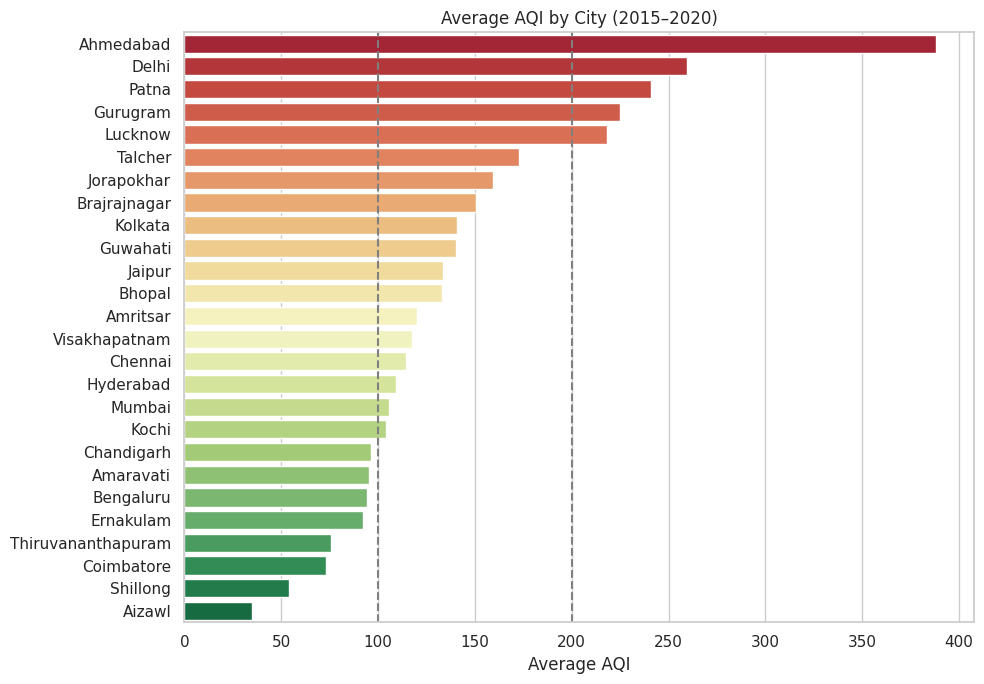

In [5]:
# 3.1 Average AQI by city
city_aqi = spark.sql("""
    SELECT City, ROUND(AVG(AQI),1) AS avg_aqi, ROUND(AVG(PM25),1) AS avg_pm25, COUNT(*) AS days
    FROM aqi GROUP BY City ORDER BY avg_aqi DESC
""").toPandas()
print(city_aqi)
results["city_aqi"] = city_aqi.to_dict(orient="records")

plt.figure(figsize=(10, 7))
sns.barplot(data=city_aqi, y="City", x="avg_aqi", hue="City", palette="RdYlGn", legend=False)
plt.axvline(100, ls="--", c="grey"); plt.axvline(200, ls="--", c="grey")
plt.title("Average AQI by City (2015–2020)"); plt.xlabel("Average AQI"); plt.ylabel("")
plt.tight_layout(); plt.savefig(f"{OUT}/01_city_avg_aqi.png", dpi=150); plt.show()

   Year  avg_aqi  cities
0  2015    211.4       7
1  2016    196.5       9
2  2017    177.8      15
3  2018    172.4      18
4  2019    152.6      23
5  2020    112.7      26


Cities with data in all 6 years: ['Patna', 'Delhi', 'Chennai', 'Lucknow', 'Ahmedabad', 'Bengaluru', 'Hyderabad']
   Year  avg_aqi
0  2015    211.4
1  2016    200.3
2  2017    179.1
3  2018    209.2
4  2019    196.1
5  2020    137.0


    Month  avg_aqi  avg_pm25
0       1    223.6     108.0
1       2    193.2      82.3
2       3    158.8      62.7
3       4    140.3      52.5
4       5    135.5      50.5
5       6    120.2      43.0
6       7    110.9      37.0
7       8    113.6      33.5
8       9    115.2      36.8
9      10    181.4      75.5
10     11    229.4     111.2
11     12    224.5     111.4


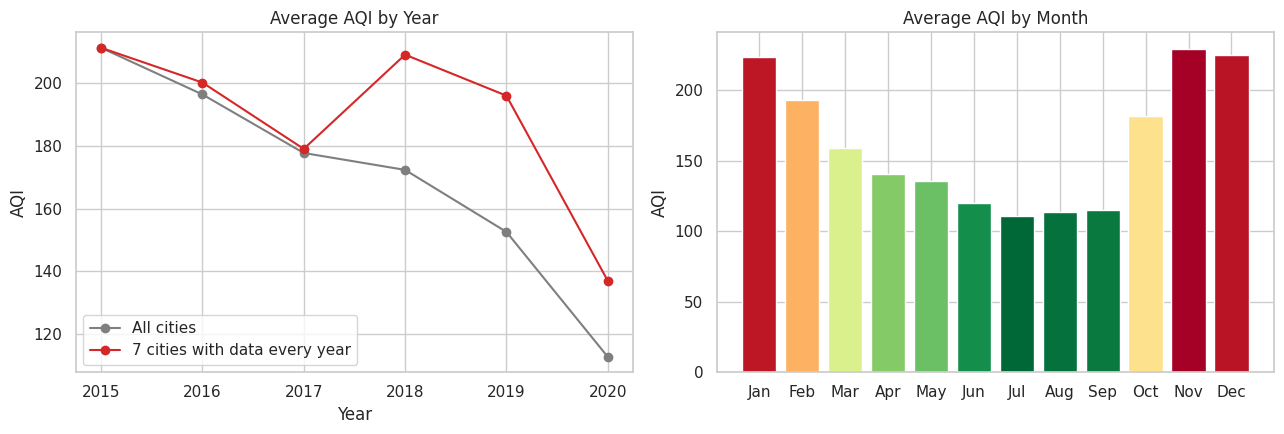

In [6]:
# 3.2 Yearly trend (national average)
yearly = spark.sql("""
    SELECT Year, ROUND(AVG(AQI),1) AS avg_aqi, COUNT(DISTINCT City) AS cities
    FROM aqi GROUP BY Year ORDER BY Year
""").toPandas()
print(yearly)
results["yearly"] = yearly.to_dict(orient="records")

# Fair comparison: only cities that have data in every year 2015-2020
# (new, cleaner cities joined the network later and would pull the average down)
yearly_fixed = spark.sql("""
    WITH full_cities AS (
        SELECT City FROM aqi GROUP BY City HAVING COUNT(DISTINCT Year) = 6
    )
    SELECT Year, ROUND(AVG(AQI),1) AS avg_aqi
    FROM aqi WHERE City IN (SELECT City FROM full_cities)
    GROUP BY Year ORDER BY Year
""").toPandas()
full_cities = [r.City for r in spark.sql(
    "SELECT City FROM aqi GROUP BY City HAVING COUNT(DISTINCT Year) = 6").collect()]
print("Cities with data in all 6 years:", full_cities)
print(yearly_fixed)
results["yearly_fixed"] = yearly_fixed.to_dict(orient="records")
results["full_cities"] = full_cities

# 3.3 Monthly pattern
monthly = spark.sql("""
    SELECT Month, ROUND(AVG(AQI),1) AS avg_aqi, ROUND(AVG(PM25),1) AS avg_pm25
    FROM aqi GROUP BY Month ORDER BY Month
""").toPandas()
print(monthly)
results["monthly"] = monthly.to_dict(orient="records")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(yearly["Year"], yearly["avg_aqi"], marker="o", c="tab:grey", label="All cities")
ax[0].plot(yearly_fixed["Year"], yearly_fixed["avg_aqi"], marker="o", c="tab:red",
           label=f"{len(full_cities)} cities with data every year")
ax[0].legend(); ax[0].set_title("Average AQI by Year"); ax[0].set_xlabel("Year"); ax[0].set_ylabel("AQI")
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
norm = plt.Normalize(monthly["avg_aqi"].min(), monthly["avg_aqi"].max())
ax[1].bar(months, monthly["avg_aqi"], color=plt.cm.RdYlGn_r(norm(monthly["avg_aqi"])))
ax[1].set_title("Average AQI by Month"); ax[1].set_ylabel("AQI")
plt.tight_layout(); plt.savefig(f"{OUT}/02_yearly_monthly_trend.png", dpi=150); plt.show()

         Season  avg_aqi
0        Winter    213.8
1  Post-Monsoon    205.6
2        Summer    144.7
3       Monsoon    115.3


     AQI_Bucket  days   pct
0      Moderate  8829  35.7
1  Satisfactory  8224  33.2
2          Poor  2781  11.2
3     Very Poor  2337   9.4
4          Good  1341   5.4
5        Severe  1245   5.0


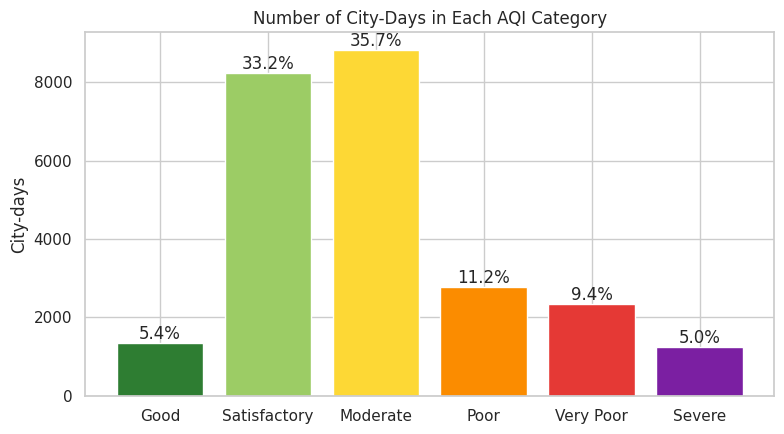

In [7]:
# 3.4 Seasonal pattern
season = spark.sql("""
    SELECT Season, ROUND(AVG(AQI),1) AS avg_aqi
    FROM aqi GROUP BY Season ORDER BY avg_aqi DESC
""").toPandas()
print(season)
results["season"] = season.to_dict(orient="records")

# 3.5 AQI category distribution
bucket = spark.sql("""
    SELECT AQI_Bucket, COUNT(*) AS days, ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM aqi),1) AS pct
    FROM aqi WHERE AQI_Bucket IS NOT NULL GROUP BY AQI_Bucket ORDER BY days DESC
""").toPandas()
print(bucket)
results["bucket"] = bucket.to_dict(orient="records")

order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
colors = ["#2e7d32", "#9ccc65", "#fdd835", "#fb8c00", "#e53935", "#7b1fa2"]
b = bucket.set_index("AQI_Bucket").reindex(order)
plt.figure(figsize=(8, 4.5))
plt.bar(order, b["days"], color=colors)
for i, v in enumerate(b["pct"]):
    plt.text(i, b["days"].iloc[i], f"{v}%", ha="center", va="bottom")
plt.title("Number of City-Days in Each AQI Category"); plt.ylabel("City-days")
plt.tight_layout(); plt.savefig(f"{OUT}/03_aqi_category_distribution.png", dpi=150); plt.show()

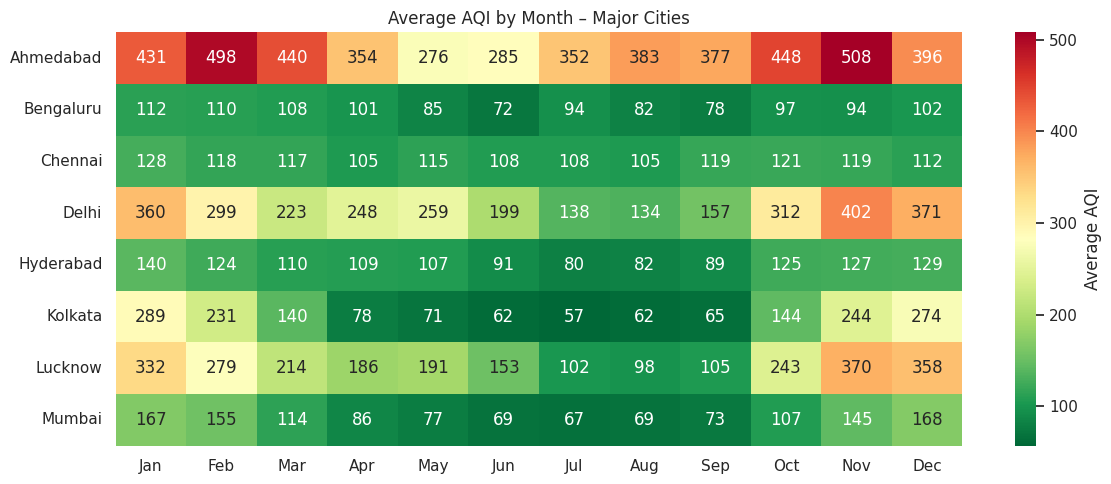

In [8]:
# 3.6 Monthly heatmap for major metro cities
metros = ["Delhi", "Mumbai", "Kolkata", "Chennai", "Bengaluru", "Hyderabad", "Ahmedabad", "Lucknow"]
heat = spark.sql(f"""
    SELECT City, Month, ROUND(AVG(AQI),0) AS avg_aqi FROM aqi
    WHERE City IN ({",".join(f"'{c}'" for c in metros)})
    GROUP BY City, Month
""").toPandas().pivot(index="City", columns="Month", values="avg_aqi")
heat.columns = months
plt.figure(figsize=(12, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "Average AQI"})
plt.title("Average AQI by Month – Major Cities"); plt.ylabel("")
plt.tight_layout(); plt.savefig(f"{OUT}/04_metro_month_heatmap.png", dpi=150); plt.show()
results["heat"] = heat.to_dict()

In [9]:
# 3.7 Why is Ahmedabad so high? Compare its pollutant averages with Delhi
diag = spark.sql("""
    SELECT City, ROUND(AVG(AQI),1) AS aqi, ROUND(AVG(PM25),1) AS pm25, ROUND(AVG(PM10),1) AS pm10,
           ROUND(AVG(CO),2) AS co, ROUND(AVG(NO2),1) AS no2, ROUND(AVG(SO2),1) AS so2
    FROM aqi WHERE City IN ('Ahmedabad','Delhi','Mumbai') GROUP BY City
""").toPandas()
print(diag)
results["diag"] = diag.to_dict(orient="records")

        City    aqi   pm25   pm10     co   no2   so2
0      Delhi  259.5  117.5  232.9   1.99  50.8  15.9
1     Mumbai  105.4   35.2   96.6   1.22  25.5  14.6
2  Ahmedabad  388.3   64.1  110.8  18.65  56.4  53.6


## 4. Module 4 – Effect of the 2020 COVID-19 Lockdown
Compare the lockdown period (25 Mar – 31 May 2020) with the same dates in 2019.

                  City  aqi_2019  aqi_2020  pm25_2019  pm25_2020  no2_2019  \
0            Ahmedabad     468.1     129.2       74.9       28.9      76.0   
1              Lucknow     204.6     111.9       93.9       55.4      35.9   
2                Delhi     225.5     125.4       86.2       48.5      49.9   
3             Gurugram     212.4     123.3       91.4       45.5      17.4   
4        Visakhapatnam     106.8      62.8       34.8       18.1      30.3   
5             Amritsar     114.6      68.8       52.6       26.3      25.9   
6            Bengaluru     116.2      70.6       45.7       23.5      30.9   
7            Amaravati      88.8      54.0       28.6       20.2      15.5   
8               Jaipur     143.8      96.5       53.3       33.0      33.1   
9            Hyderabad     105.6      71.8       41.4       30.6      32.6   
10             Kolkata      93.8      65.8       45.2       22.7      26.7   
11              Mumbai      95.6      69.8       19.6       19.5

{'aqi_2019': 147.3, 'aqi_2020': 93.9, 'pm25_2019': 52.4, 'pm25_2020': 32.7, 'no2_2019': 26.0, 'no2_2020': 14.8}


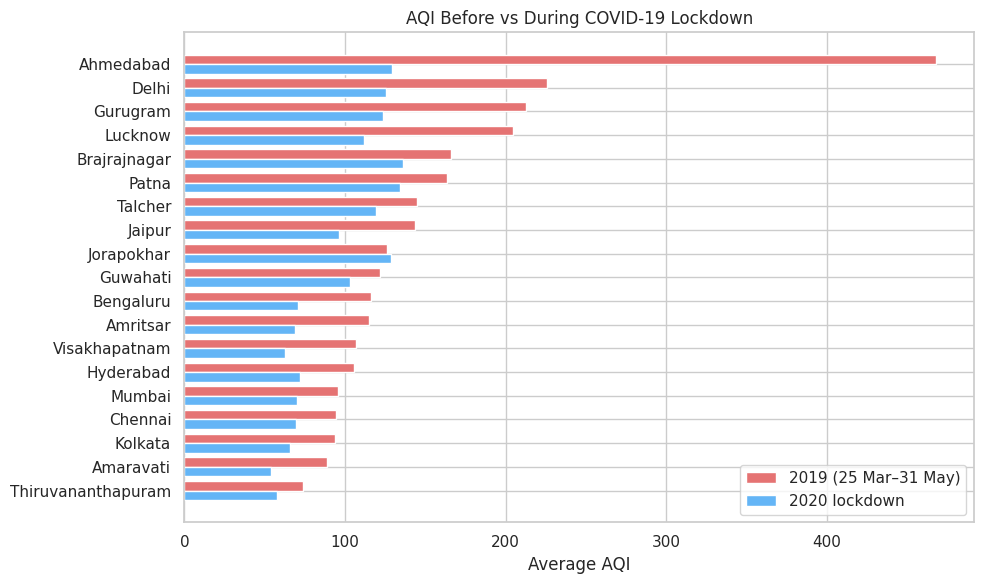

In [10]:
lockdown = spark.sql("""
    SELECT City,
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN AQI END),1) AS aqi_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN AQI END),1) AS aqi_2020,
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN PM25 END),1) AS pm25_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN PM25 END),1) AS pm25_2020,
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN NO2 END),1) AS no2_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN NO2 END),1) AS no2_2020
    FROM aqi GROUP BY City
""").dropna(subset=["aqi_2019", "aqi_2020"]) \
    .withColumn("aqi_change_pct", F.round((F.col("aqi_2020") - F.col("aqi_2019")) / F.col("aqi_2019") * 100, 1)) \
    .orderBy("aqi_change_pct").toPandas()
print(lockdown)
results["lockdown"] = lockdown.to_dict(orient="records")

overall = spark.sql("""
    SELECT
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN AQI END),1) AS aqi_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN AQI END),1) AS aqi_2020,
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN PM25 END),1) AS pm25_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN PM25 END),1) AS pm25_2020,
      ROUND(AVG(CASE WHEN Date BETWEEN '2019-03-25' AND '2019-05-31' THEN NO2 END),1) AS no2_2019,
      ROUND(AVG(CASE WHEN Date BETWEEN '2020-03-25' AND '2020-05-31' THEN NO2 END),1) AS no2_2020
    FROM aqi WHERE City IN ({})
""".format(",".join(f"'{c}'" for c in lockdown["City"]))).toPandas().iloc[0].to_dict()
print(overall)
results["lockdown_overall"] = {k: float(v) for k, v in overall.items()}

plt.figure(figsize=(10, 6))
ld = lockdown.sort_values("aqi_2019", ascending=True)
y = range(len(ld))
plt.barh([i + 0.2 for i in y], ld["aqi_2019"], height=0.4, label="2019 (25 Mar–31 May)", color="#e57373")
plt.barh([i - 0.2 for i in y], ld["aqi_2020"], height=0.4, label="2020 lockdown", color="#64b5f6")
plt.yticks(list(y), ld["City"]); plt.xlabel("Average AQI")
plt.title("AQI Before vs During COVID-19 Lockdown"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/05_lockdown_comparison.png", dpi=150); plt.show()

## 5. Module 5 – Correlation of Pollutants with AQI

PM25       0.725
CO         0.556
NO2        0.511
NO         0.444
NOx        0.441
SO2        0.434
PM10       0.305
Toluene    0.265
O3         0.208
Xylene     0.153
Benzene    0.039
NH3        0.003
dtype: float64


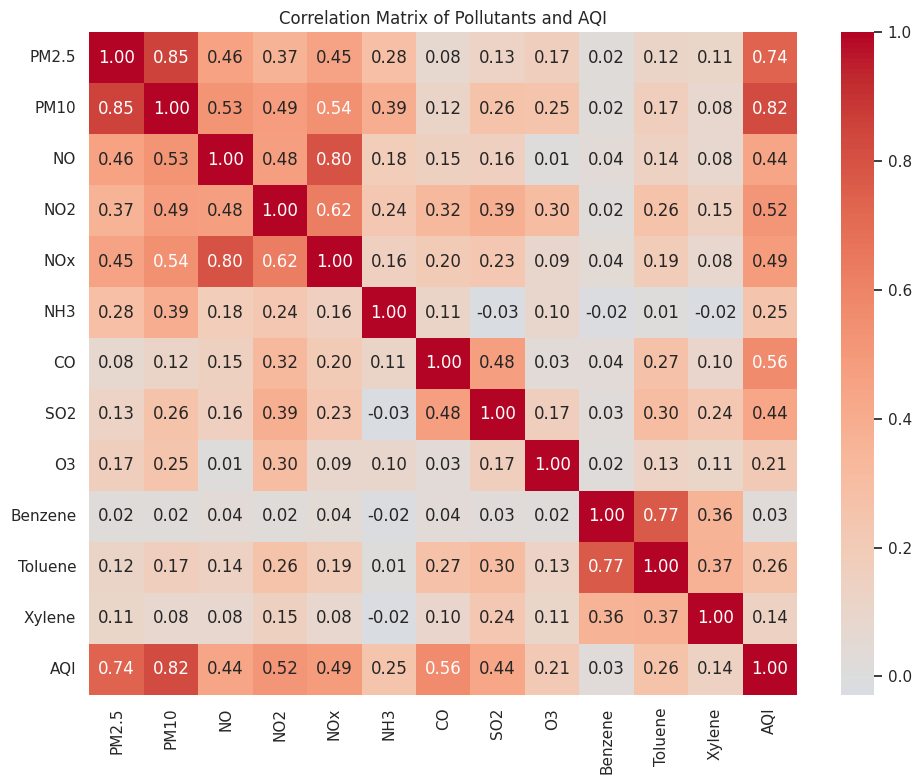

In [11]:
corr = {c: round(clean.stat.corr(c, "AQI"), 3) for c in POLL}
corr_s = pd.Series(corr).sort_values(ascending=False)
print(corr_s)
results["corr"] = corr_s.to_dict()

pdf = clean.select(POLL + ["AQI"]).toPandas().rename(columns={"PM25": "PM2.5"})
plt.figure(figsize=(10, 8))
sns.heatmap(pdf.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Pollutants and AQI")
plt.tight_layout(); plt.savefig(f"{OUT}/06_correlation_heatmap.png", dpi=150); plt.show()

## 6. Module 6 – AQI Prediction with Spark MLlib
Features: 12 pollutant concentrations. Target: AQI.
Missing feature values are filled with the median (Imputer). Data split 80% train / 20% test.

In [12]:
ml_df = clean.select(POLL + ["AQI"])
imputed_cols = [c + "_imp" for c in POLL]
imputer = Imputer(inputCols=POLL, outputCols=imputed_cols, strategy="median")
assembler = VectorAssembler(inputCols=imputed_cols, outputCol="features")

train, test = ml_df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train.count(), "| Test rows:", test.count())

models = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="AQI"),
    "Decision Tree": DecisionTreeRegressor(featuresCol="features", labelCol="AQI", maxDepth=8, seed=42),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="AQI",
                                           numTrees=100, maxDepth=10, seed=42),
    "Gradient Boosted Trees": GBTRegressor(featuresCol="features", labelCol="AQI",
                                           maxIter=60, maxDepth=6, seed=42),
}

ev = {m: RegressionEvaluator(labelCol="AQI", predictionCol="prediction", metricName=m)
      for m in ["rmse", "mae", "r2"]}
metrics, fitted, preds = [], {}, {}
for name, algo in models.items():
    model = Pipeline(stages=[imputer, assembler, algo]).fit(train)
    p = model.transform(test)
    row = {"Model": name, **{k.upper() if k != "r2" else "R2": round(e.evaluate(p), 3) for k, e in ev.items()}}
    print(row)
    metrics.append(row); fitted[name] = model; preds[name] = p
metrics_df = pd.DataFrame(metrics).sort_values("RMSE")
print(metrics_df)
results["metrics"] = metrics_df.to_dict(orient="records")

Train rows: 19930 | Test rows: 4827


{'Model': 'Linear Regression', 'RMSE': 48.821, 'MAE': 30.468, 'R2': 0.843}


{'Model': 'Decision Tree', 'RMSE': 43.797, 'MAE': 24.855, 'R2': 0.874}


{'Model': 'Random Forest', 'RMSE': 37.337, 'MAE': 21.758, 'R2': 0.908}


{'Model': 'Gradient Boosted Trees', 'RMSE': 40.312, 'MAE': 21.753, 'R2': 0.893}
                    Model    RMSE     MAE     R2
2           Random Forest  37.337  21.758  0.908
3  Gradient Boosted Trees  40.312  21.753  0.893
1           Decision Tree  43.797  24.855  0.874
0       Linear Regression  48.821  30.468  0.843


Best model: Random Forest
PM2.5      0.381977
CO         0.219764
PM10       0.153384
NO2        0.061562
NOx        0.047571
NO         0.039329
SO2        0.033768
Toluene    0.023032
O3         0.012293
NH3        0.010484
Xylene     0.008675
Benzene    0.008159
dtype: float64


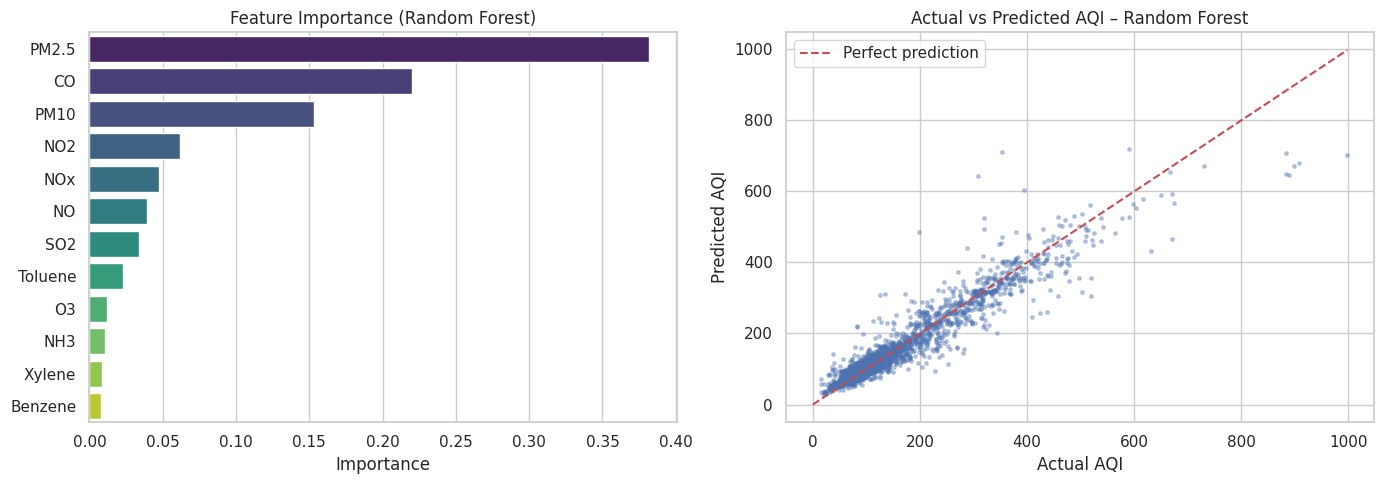

In [13]:
best_name = metrics_df.iloc[0]["Model"]
print("Best model:", best_name)
results["best"] = best_name

# Feature importance from Random Forest
rf = fitted["Random Forest"].stages[-1]
imp = pd.Series(rf.featureImportances.toArray(), index=POLLUTANTS).sort_values(ascending=False)
print(imp)
results["importance"] = imp.round(4).to_dict()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=imp.values, y=imp.index, ax=ax[0], hue=imp.index, palette="viridis", legend=False)
ax[0].set_title("Feature Importance (Random Forest)"); ax[0].set_xlabel("Importance"); ax[0].set_ylabel("")
sample = preds[best_name].select("AQI", "prediction").sample(fraction=0.5, seed=1).toPandas()
ax[1].scatter(sample["AQI"], sample["prediction"], s=6, alpha=0.35)
lim = [0, max(sample["AQI"].max(), sample["prediction"].max())]
ax[1].plot(lim, lim, "r--", label="Perfect prediction")
ax[1].set_xlabel("Actual AQI"); ax[1].set_ylabel("Predicted AQI")
ax[1].set_title(f"Actual vs Predicted AQI – {best_name}"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/07_model_results.png", dpi=150); plt.show()

In [14]:
# Predict AQI for a new day (example input)
example = spark.createDataFrame([(180.0, 300.0, 20.0, 60.0, 50.0, 40.0, 1.5, 15.0, 40.0, 4.0, 15.0, 3.0)],
                                POLL)
pred = fitted[best_name].transform(example.withColumn("AQI", F.lit(0.0))).select("prediction").first()[0]
print(f"Predicted AQI for example input: {pred:.0f}")
results["example_pred"] = round(pred, 1)

Predicted AQI for example input: 364


## 7. Module 7 – Calculating Every Day's AQI (CPCB method)
The Indian National AQI is calculated in two steps:
1. Each pollutant's concentration is converted to a **sub-index** (0–500) using CPCB breakpoint tables
   (straight-line interpolation between breakpoints).
2. The day's **AQI = the highest sub-index**. It is only valid when at least 3 pollutants are measured,
   and at least one of them is PM2.5 or PM10.

We calculate this for **every city-day in the dataset (all 29,531 rows)**, including days where the
recorded AQI is missing, and compare our values with the recorded AQI.
The same breakpoint table is exported to JSON so the web dashboard (frontend) uses identical logic.

In [15]:
# CPCB breakpoints: concentration breakpoints -> AQI breakpoints [0, 50, 100, 200, 300, 400, 500]
AQI_BP = [0, 50, 100, 200, 300, 400, 500]
CONC_BP = {
    "PM25": [0, 30, 60, 90, 120, 250, 380],      # µg/m³, 24-hour
    "PM10": [0, 50, 100, 250, 350, 430, 510],    # µg/m³, 24-hour
    "NO2":  [0, 40, 80, 180, 280, 400, 520],     # µg/m³, 24-hour
    "SO2":  [0, 40, 80, 380, 800, 1600, 2400],   # µg/m³, 24-hour
    "CO":   [0, 1, 2, 10, 17, 34, 51],           # mg/m³, 8-hour
    "O3":   [0, 50, 100, 168, 208, 748, 1288],   # µg/m³, 8-hour
    "NH3":  [0, 200, 400, 800, 1200, 1800, 2400] # µg/m³, 24-hour
}
# (The last breakpoint continues the slope of the "Severe" band, so values above it keep rising.)

def sub_index(col_name):
    """Build a Spark column expression for one pollutant's CPCB sub-index."""
    c, bp = F.col(col_name), CONC_BP[col_name]
    expr = None
    for i in range(1, len(bp)):
        lo_c, hi_c, lo_i, hi_i = bp[i-1], bp[i], AQI_BP[i-1], AQI_BP[i]
        seg = lo_i + (c - lo_c) * (hi_i - lo_i) / (hi_c - lo_c)
        cond = (c <= hi_c) if i < len(bp) - 1 else F.lit(True)   # last band: open-ended
        expr = F.when(cond, seg) if expr is None else expr.when(cond, seg)
    return F.when(c.isNull(), None).otherwise(expr)

SI_COLS = list(CONC_BP.keys())
daily = (df.withColumn("Date", F.to_date("Date"))
           .dropDuplicates(["City", "Date"]))
for c in SI_COLS:
    daily = daily.withColumn(c, F.when(F.col(c) < 0, None).otherwise(F.col(c).cast(DoubleType())))
    daily = daily.withColumn(f"SI_{c}", sub_index(c))

si = [F.col(f"SI_{c}") for c in SI_COLS]
n_valid = sum(F.when(x.isNotNull(), 1).otherwise(0) for x in si)
has_pm = F.col("SI_PM25").isNotNull() | F.col("SI_PM10").isNotNull()
daily = daily.withColumn("AQI_calc",
    F.when((n_valid >= 3) & has_pm, F.round(F.greatest(*si))).otherwise(None))

# Dominant pollutant = the one whose sub-index equals the AQI
dom = None
for c in SI_COLS:
    cond = F.round(F.col(f"SI_{c}")) == F.col("AQI_calc")
    dom = F.when(cond, F.lit(c.replace("PM25", "PM2.5"))) if dom is None else dom.when(cond, F.lit(c.replace("PM25", "PM2.5")))
daily = daily.withColumn("Dominant", dom)

def bucket(col):
    return (F.when(col <= 50, "Good").when(col <= 100, "Satisfactory").when(col <= 200, "Moderate")
             .when(col <= 300, "Poor").when(col <= 400, "Very Poor").otherwise("Severe"))
daily = daily.withColumn("Bucket_calc", F.when(F.col("AQI_calc").isNull(), None).otherwise(bucket(F.col("AQI_calc"))))
daily.cache()
daily.createOrReplaceTempView("daily")

In [16]:
check = spark.sql("""
    SELECT COUNT(*)                                             AS total_days,
           SUM(CASE WHEN AQI_calc IS NOT NULL THEN 1 ELSE 0 END) AS calculated_days,
           SUM(CASE WHEN AQI IS NOT NULL THEN 1 ELSE 0 END)      AS recorded_days,
           SUM(CASE WHEN AQI IS NULL AND AQI_calc IS NOT NULL THEN 1 ELSE 0 END) AS gaps_filled,
           SUM(CASE WHEN AQI IS NOT NULL AND AQI_calc IS NOT NULL THEN 1 ELSE 0 END) AS both_days,
           ROUND(AVG(CASE WHEN AQI IS NOT NULL AND AQI_calc IS NOT NULL THEN ABS(AQI - AQI_calc) END), 1) AS mae,
           ROUND(AVG(CASE WHEN AQI IS NOT NULL AND AQI_calc IS NOT NULL
                          THEN CASE WHEN AQI_Bucket = Bucket_calc THEN 1.0 ELSE 0.0 END END) * 100, 1) AS bucket_match_pct
    FROM daily
""").toPandas().iloc[0].to_dict()
check["corr"] = round(daily.filter("AQI IS NOT NULL AND AQI_calc IS NOT NULL").stat.corr("AQI", "AQI_calc"), 3)
check = {k: (float(v) if not isinstance(v, str) else v) for k, v in check.items()}
print(check)
results["daily_check"] = check

dominant = spark.sql("""
    SELECT Dominant, COUNT(*) AS days, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (), 1) AS pct
    FROM daily WHERE Dominant IS NOT NULL GROUP BY Dominant ORDER BY days DESC
""").toPandas()
print(dominant)
results["dominant"] = dominant.to_dict(orient="records")

{'total_days': 29531.0, 'calculated_days': 25680.0, 'recorded_days': 24850.0, 'gaps_filled': 895.0, 'both_days': 24785.0, 'mae': 29.7, 'bucket_match_pct': 70.5, 'corr': 0.884}


  Dominant   days   pct
0    PM2.5  10632  41.4
1     PM10   9825  38.3
2       CO   3953  15.4
3       O3    798   3.1
4      NO2    378   1.5
5      SO2     80   0.3
6      NH3     14   0.1


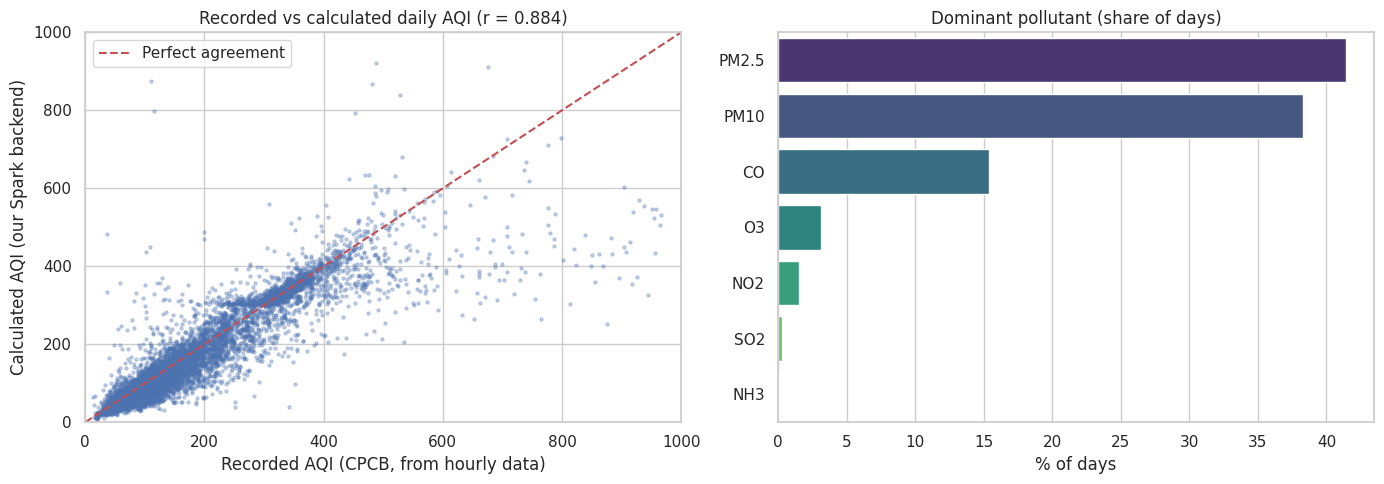

In [17]:
# Chart: recorded vs calculated AQI
both = daily.filter("AQI IS NOT NULL AND AQI_calc IS NOT NULL").select("AQI", "AQI_calc") \
            .sample(fraction=0.4, seed=7).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(both["AQI"], both["AQI_calc"], s=5, alpha=0.3)
lim = [0, 1000]
ax[0].plot(lim, lim, "r--", label="Perfect agreement"); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Recorded AQI (CPCB, from hourly data)"); ax[0].set_ylabel("Calculated AQI (our Spark backend)")
ax[0].set_title(f"Recorded vs calculated daily AQI (r = {check['corr']})"); ax[0].legend()
sns.barplot(data=dominant, x="pct", y="Dominant", ax=ax[1], hue="Dominant", palette="viridis", legend=False)
ax[1].set_title("Dominant pollutant (share of days)"); ax[1].set_xlabel("% of days"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(f"{OUT}/08_daily_aqi_check.png", dpi=150); plt.show()

In [18]:
# Save every day's AQI (backend output) for the report and the web dashboard
out_cols = ["City", "Date", "PM25", "PM10", "NO2", "SO2", "CO", "O3", "NH3",
            "AQI", "AQI_calc", "Bucket_calc", "Dominant"]
daily_pd = daily.select(out_cols).orderBy("City", "Date").toPandas()
daily_pd.rename(columns={"PM25": "PM2.5", "AQI": "AQI_recorded"}).to_csv(f"{OUT}/daily_aqi.csv", index=False)

# Compact JSON for the frontend: one array per city, one entry per day
import math
def clean(v, nd=2):
    return None if v is None or (isinstance(v, float) and math.isnan(v)) else round(float(v), nd)
web = {"breakpoints": {"aqi": AQI_BP, "conc": CONC_BP}, "cities": {}}
for city, g in daily_pd.groupby("City"):
    web["cities"][city] = [[str(r.Date)[:10],
                            clean(r.PM25), clean(r.PM10), clean(r.NO2), clean(r.SO2), clean(r.CO),
                            clean(r.O3), clean(r.NH3), clean(r.AQI, 0), clean(r.AQI_calc, 0)]
                           for r in g.itertuples()]
with open(f"{OUT}/daily_aqi_web.json", "w") as f:
    json.dump(web, f, separators=(",", ":"))
print("Saved", len(daily_pd), "daily rows")

Saved 29531 daily rows


In [19]:
with open(f"{OUT}/results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
spark.stop()
print("Done. Charts saved in", OUT)

Done. Charts saved in outputs
